# Housekeeping


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from pathlib import Path


from typing import Callable, List, Dict
import warnings
warnings.filterwarnings("ignore")

%load_ext google.colab.data_table

HERE = Path.cwd().resolve().parent
DATASETS = HERE.parent/'datasets'

Mounted at /content/drive


In [ ]:
from matplotlib import rcParams

# Set global font sizes
rcParams.update({
    'axes.titlesize': 18,       # Title font size
    'axes.labelsize': 16,       # X and Y label font size
    'axes.labelweight': 'bold',
    'xtick.labelsize': 14,      # X tick label font size
    'ytick.labelsize': 14,      # Y tick label font size
    'legend.fontsize': 14,      # Legend font size
    'font.size': 14             # Default font size
})


In [ ]:
raw_folder = DATASETS/ "extracted_files"
data_folder = DATASETS/ "processed"

In [ ]:
raw_dataset: pd.DataFrame = pd.read_csv(raw_folder/'grouped_tunneling_J.csv')
# raw_data_with_weather_conditions: pd.DataFrame = pd.read_csv(data_folder / "grouped_data_with_weather_report.csv")

In [ ]:
raw_dataset.shape

(18834, 25)

# Missing Values

In [ ]:
def missing_percent_and_points(df:pd.DataFrame, mssing_threshold:int):
  missing_percentage: pd.Series = df.isnull().sum().sort_values(ascending=False)*100/len(df)
  missing_points: pd.Series = df.isnull().sum().sort_values(ascending=False)  # mask on dataframe for missing points?

  list_param: list[str] = missing_percentage.index.to_list()
  missed_values_percent: list[float] = missing_percentage.to_list()
  missed_points_values: list = missing_points.to_list()

  mis_df = pd.DataFrame({
    "Parameters": list_param,
    "missed_Percentage": missed_values_percent,
    "missing_Points": missed_points_values
     })
  mis_df= mis_df[mis_df['missed_Percentage']<=mssing_threshold]
  mis_df['availability_Percentage'] = 100 - mis_df['missed_Percentage']

  return mis_df

df_miss_under80 = missing_percent_and_points(raw_dataset, mssing_threshold=80)

In [ ]:
df_miss_under80

,Parameters,missed_Percentage,missing_Points,availability_Percentage
0,autozero time,1.608793,303,98.391207
1,delay,1.608793,303,98.391207
2,NPLC,1.608793,303,98.391207
3,step,1.608793,303,98.391207
4,V(start/end),1.608793,303,98.391207
5,V(low),1.608793,303,98.391207
6,V(high),1.608793,303,98.391207
7,start time,1.608793,303,98.391207
8,date,1.608793,303,98.391207
9,Junction diameter,1.608793,303,98.391207


## drop nans and tests (_True, pool all and dummies)

In [ ]:
cleaned_data = raw_dataset.dropna().reset_index(drop=True)
cleaned_data.shape

(18529, 25)

In [ ]:
cleaned_data = cleaned_data[~cleaned_data['path'].str.contains('_True')]
cleaned_data = cleaned_data[~cleaned_data['path'].str.contains('pool all')]


In [ ]:
print(f"dropped pool _True:         {cleaned_data.shape}")
print(f"dropped pool all and _True: {cleaned_data.shape}")

dropped pool _True:         (17715, 25)
dropped pool all and _True: (17715, 25)



```
Some fild patterns
x 1 […] (e.g., 1 1, 2 1)
```



In [ ]:
def is_single_test(file_path):
    # Extract the file name from the path
    file_name = file_path.split('\\')[-1]  # Get the last part after the last backslash
    return '-' not in file_name  # Return True if it doesn't contain a hyphen

# Filter the DataFrame to drop single tests
df_containing_tests = cleaned_data[cleaned_data['path'].apply(is_single_test)]
cleaned_data = cleaned_data[~cleaned_data['path'].apply(is_single_test)]


In [ ]:
print(f"dropped tests dataset:         {cleaned_data.shape}")

dropped tests dataset:         (16156, 25)


*Limit carbon chain length to C9-C18*

In [ ]:
cleaned_data = cleaned_data[(cleaned_data['carbon number'] >= 9) & (cleaned_data['carbon number'] <= 18)]
print(f"removed redundent carbons dataset: {cleaned_data.shape}")

removed redundent carbons dataset: (14004, 25)


# Find duplicates, triplicates


In [ ]:
working_data_duplicates =cleaned_data.copy()

In [ ]:
working_data_duplicates['log_absJ']

,log_absJ
1,"[-6.016635586149714, -3.9582489723649963, -3.6..."
2,"[-6.1442275494782095, -5.113225778720591, -3.7..."
3,"[-6.878737337215404, -4.077812164883306, -3.72..."
4,"[-6.117008235012866, -5.115111388824767, -3.72..."
5,"[-6.102887385002299, -5.115713970770625, -3.73..."
...,...
18524,"[-5.929202136596379, -3.618218188877938, -3.28..."
18525,"[-5.787515684673542, -3.7230159778325844, -3.5..."
18526,"[-5.79869957842396, -3.6963092151887604, -3.55..."
18527,"[-5.861963013399091, -3.646347040161084, -3.55..."


In [ ]:
def check_duplicates(df):
    pairs = set()
    triplets = set()
    quadruples = set()
    seen_hashes = {}
    all_duplicates_idx = set()

    for i in df.index:
        value = tuple(df.loc[i, 'log_absJ'])  # assuming it's an array

        hash_value = hash(value)

        if hash_value in seen_hashes:
            seen_hashes[hash_value].append(i)
        else:
            seen_hashes[hash_value] = [i]

    for indices in seen_hashes.values():
        if len(indices) > 1:
            all_duplicates_idx.add(tuple(indices))
        if len(indices) == 2:
            pairs.add(tuple(indices))
        if len(indices) == 3:
            triplets.add(tuple(indices))
        if len(indices) == 4:
            quadruples.add(tuple(indices))

    print(f'number of pairs :{len(pairs)}')
    print(f'number of triplet:{len(triplets)}')
    print(f'number of quadruples:{len(quadruples)}')
    return pairs, triplets, quadruples

pair, triplet , quadrupel = check_duplicates(working_data_duplicates)


pair, triplet , quadrupel = check_duplicates(working_data_duplicates)


number of pairs :483
number of triplet:0
number of quadruples:0
number of pairs :483
number of triplet:0
number of quadruples:0


In [ ]:
from inspect import cleandoc
# adding pairs to rows:
def add_pair_matches(df, pairs_set,triplet_set):
    """
    Adds a 'Pair match' column to the DataFrame based on the set of index pairs.

    Args:
        df (pd.DataFrame): The input DataFrame with index values.
        my_pairs (set): A set of tuples containing pairs of indices.

    Returns:
        pd.DataFrame: The updated DataFrame with the 'Pair match' column.
    """
    # Create 'Pair match' column initialized with None
    df['Pair match'] = None

    # Loop through the pairs and assign them to corresponding rows
    for idx1, idx2 in pairs_set:
        if idx1 in df.index and idx2 in df.index:
            df.at[idx1, 'Pair match'] = (idx1, idx2)
            df.at[idx2, 'Pair match'] = (idx1, idx2)

    for idx1, idx2, idx3 in triplet_set:
      if idx1 in df.index and idx2 in df.index and idx3 in df.index:
          # Assign the same triplet to all three indices
          df.at[idx1, 'Pair match'] = (idx1, idx2, idx3)
          df.at[idx2, 'Pair match'] = (idx1, idx2, idx3)
          df.at[idx3, 'Pair match'] = (idx1, idx2, idx3)

    return df


In [ ]:
working_data_duplicates = add_pair_matches(working_data_duplicates, pair, triplet)


In [ ]:
working_data_duplicates['Pair match'].nunique()

483

In [ ]:
columns_to_compare = [ 'date','start time', 'location', 'carbon number', 'electrode']

def compare_columns_in_groups(df, camparing_col):
    """
    Compares specified columns within groups in a DataFrame and identifies differences.

    Args:
        df (pd.DataFrame): The input DataFrame with a 'Pair match' or 'Triplet match' column.
        columns_to_compare (list): A list of columns to compare within each group.

    Returns:
        pd.DataFrame: A DataFrame that shows where the differences occur in the specified columns.
    """
    # Filter rows where 'Pair match' or 'Triplet match' is not null

    # Group by 'Pair match' or 'Triplet match'
    grouped_pairs = df.groupby('Pair match')

    # Create an empty list to store the comparison results
    differences = []

    # Loop through each group
    for name, group in grouped_pairs:
        # Create a dictionary to store the differences for this group
        group_differences = {'Pair match': name}

        # Compare each specified column in the group
        for col in camparing_col:
            # Check if all values in the column are the same for the group
            if group[col].nunique() > 1:
                group_differences[col] = 'Different'
            else:
                group_differences[col] = 'Same'

        # Append the differences to the list
        differences.append(group_differences)

    # Convert the differences list to a DataFrame
    differences_df = pd.DataFrame(differences)

    return differences_df


differences = compare_columns_in_groups(working_data_duplicates, columns_to_compare)

In [ ]:
# df_containing_duplicates = compare_columns_in_groups(working_data_duplicates, columns_to_compare)


In [ ]:
def identify_differences(df, columns_to_compare):
    """
    Identify differences in the specified columns between pairs/triplets of rows.

    Args:
        df (pd.DataFrame): DataFrame containing the 'Pair match' column and other data.
        columns_to_compare (list): List of columns to compare between the pairs/triplets.

    Returns:
        pd.DataFrame: The updated DataFrame with a new 'different item' column.
    """
    # Create an empty 'different item' column
    df['different item'] = None

    # Group by 'Pair match'
    grouped = df.groupby('Pair match')

    # Iterate over each group
    for name, group in grouped:
        # List to store columns where values differ
        different_columns = []

        # Check each column in columns_to_compare for differences
        for column in columns_to_compare:
            if len(group[column].unique()) > 1:  # If there are more than 1 unique value, there is a difference
                different_columns.append(column)

        # Assign the list of different columns to the 'different item' column for this group
        df.loc[group.index, 'different item'] = ', '.join(different_columns) if different_columns else None

    return df



In [ ]:
# df_containing_duplicates = identify_differences(differences, columns_to_compare)
working_data_duplicates = identify_differences(working_data_duplicates, columns_to_compare)

In [ ]:
# working_data_duplicates[working_data_duplicates['different item']=='carbon number']

In [ ]:
def create_column_difference_heatmap(df, columns_to_compare, font_size=14):
    """
    Creates a heatmap showing how often differences in each column pair co-occur.

    Args:
        df (pd.DataFrame): DataFrame containing differences for each group.
        columns_to_compare (list): List of columns that were compared.
        font_size (int): Font size for all heatmap text elements.

    Returns:
        None: Displays the heatmap.
    """
    # Initialize a square matrix to store counts of co-occurring differences
    co_occurrence_matrix = pd.DataFrame(0, index=columns_to_compare, columns=columns_to_compare)

    # Iterate over each row in the differences DataFrame
    for _, row in df.iterrows():
        different_columns = [col for col in columns_to_compare if row[col] == 'Different']
        for i in range(len(different_columns)):
            for j in range(i, len(different_columns)):
                col_i, col_j = different_columns[i], different_columns[j]
                co_occurrence_matrix.loc[col_i, col_j] += 1
                if col_i != col_j:
                    co_occurrence_matrix.loc[col_j, col_i] += 1

    # Create the heatmap
    plt.figure(figsize=(7, 6))
    ax = sns.heatmap(
        co_occurrence_matrix,
        annot=True,
        cmap="rocket_r",
        fmt="d",
        cbar_kws={'label': 'Number of Co-occurrences'},
        annot_kws={"size": font_size}
    )

    # Set font size for title and labels
    # ax.set_title('Heatmap of Column Differences in Data Pairs', fontsize=font_size)
    ax.set_xlabel('Columns', fontsize=font_size+2)
    ax.set_ylabel('Columns', fontsize=font_size+2)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=font_size-2,rotation=45)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=font_size-2,rotation=45)

    # Set font size for colorbar label and ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(font_size)
    cbar.ax.tick_params(labelsize=font_size)

    plt.tight_layout()
    plt.show()

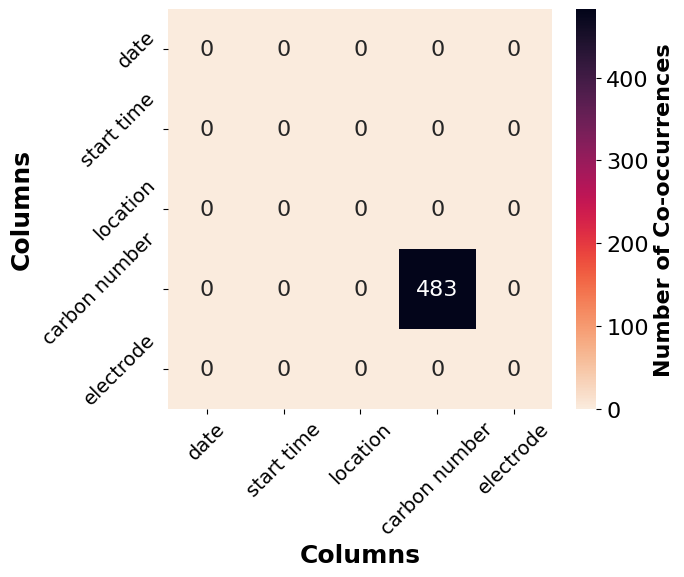

In [ ]:
create_column_difference_heatmap(differences,columns_to_compare,font_size=16)

## Exclude Carbon number from main analysis

In [ ]:
df_carbon_number_difference_only = working_data_duplicates[working_data_duplicates['different item'] == 'carbon number']

# Drop rows where 'different item' is 'carbon number'
working_data_duplicates_dropped_final = working_data_duplicates[working_data_duplicates['different item'] != 'carbon number']

In [ ]:
print(f"df with duplicated carbon number:            {df_carbon_number_difference_only.shape}")
print(f"df dropped duplicated carbon number:         {working_data_duplicates_dropped_final.shape}")

df with duplicated carbon number:            (966, 27)
df dropped duplicated carbon number:         (13038, 27)


## Final check for duplicates

In [ ]:
working_data_duplicates_dropped_final.reset_index(drop=True,inplace=True)

In [ ]:
pair, triplet, quadrupel = check_duplicates(working_data_duplicates_dropped_final)

number of pairs :0
number of triplet:0
number of quadruples:0


In [ ]:
all_final_duplicated = working_data_duplicates_dropped_final[working_data_duplicates_dropped_final['Pair match'].notna()]

In [ ]:
all_final_duplicated

,location,carbon number,electrode,voltage,absJ,log_absJ,J,current,time,date,...,autozero time,number of V(high) to V(low) spans,Junction diameter,Magnification,scan V direction,spot ID,scan ID,path,Pair match,different item


In [ ]:
working_data_duplicates_dropped_final = working_data_duplicates_dropped_final.drop(columns=['Pair match', 'different item'])

In [ ]:
# add substrate ID from path
def is_single_test(file_path):
    sub_name = file_path.split('\\')[-2]
    return sub_name

working_data_duplicates_dropped_final['substrate ID']=working_data_duplicates_dropped_final['path'].apply(is_single_test)

# Export File

In [ ]:
working_data_duplicates_dropped_final.to_csv(data_folder/"cleaned_dataset_filtered_by_carbon_number_dropped_tests.csv",index=False)